In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df1 = pd.read_csv('/datasets/project_sql_result_01.csv')
df4 = pd.read_csv('/datasets/project_sql_result_04.csv')

In [4]:
print(df1.head())
print(df1.info())
print(df1.describe())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000


In [5]:
print(df4.head())
print(df4.info())
print(df4.describe())


  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667


In [6]:
print("\nTipos de dados - df1:")
print(df1.dtypes)
print("\nTipos de dados - df4:")
print(df4.dtypes)


Tipos de dados - df1:
company_name    object
trips_amount     int64
dtype: object

Tipos de dados - df4:
dropoff_location_name     object
average_trips            float64
dtype: object


In [7]:
print("\nValores ausentes - df1:")
print(df1.isnull().sum())
print("\nValores ausentes - df4:")
print(df4.isnull().sum())


Valores ausentes - df1:
company_name    0
trips_amount    0
dtype: int64

Valores ausentes - df4:
dropoff_location_name    0
average_trips            0
dtype: int64


In [8]:
top10 = df4.sort_values('average_trips', ascending=False).head(10)
print("\nTop 10 bairros de destino:")
print(top10)


Top 10 bairros de destino:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


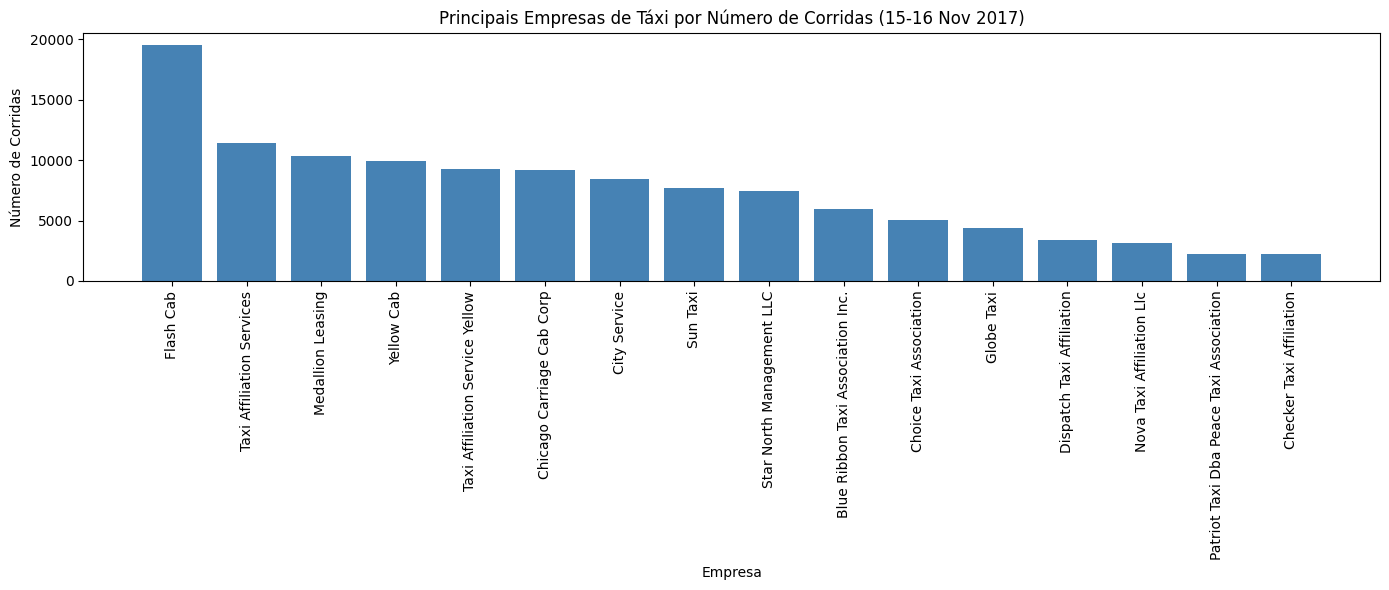

In [10]:
df1_sorted = df1.sort_values('trips_amount', ascending=False)
threshold = df1['trips_amount'].quantile(0.75)
df1_filtered = df1_sorted[df1_sorted['trips_amount'] >= threshold]

plt.figure(figsize=(14, 6))
plt.bar(df1_filtered['company_name'], df1_filtered['trips_amount'], color='steelblue')
plt.xticks(rotation=90)
plt.title('Principais Empresas de Táxi por Número de Corridas (15-16 Nov 2017)')
plt.xlabel('Empresa')
plt.ylabel('Número de Corridas')
plt.tight_layout()
plt.show()

O mercado de táxi em Chicago é claramente dominado por poucos grandes players. A Flash Cab lidera com folga, registrando quase o dobro de corridas da segunda colocada, a Taxi Affiliation Services. Quando olhamos para o conjunto total de empresas, a grande maioria mal aparece no mercado, enquanto algumas poucas movimentam volumes enormes, a maioria luta por uma fatia bem pequena do bolo.

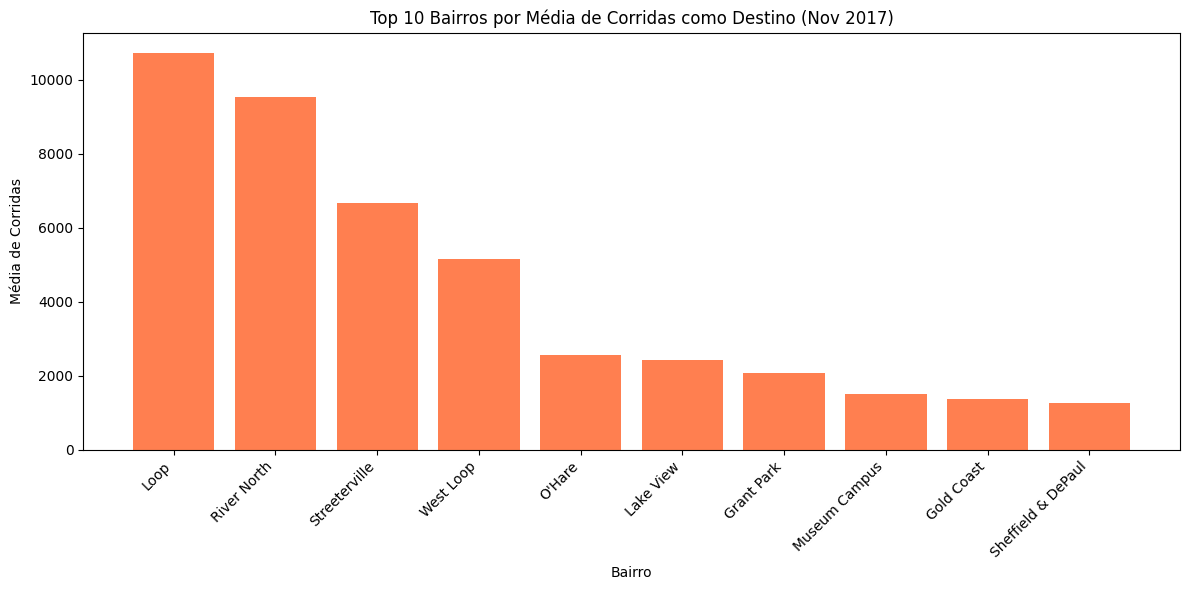

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(top10['dropoff_location_name'], top10['average_trips'], color='coral')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Bairros por Média de Corridas como Destino (Nov 2017)')
plt.xlabel('Bairro')
plt.ylabel('Média de Corridas')
plt.tight_layout()
plt.show()

Não surpreende que o Loop, coração financeiro e comercial de Chicago, seja de longe o destino mais procurado. River North e Streeterville aparecem logo atrás, reforçando que as regiões centrais concentram a maior parte da demanda. Um dado interessante é o Aeroporto O'Hare figurando entre os top 5, o que mostra que a rota para o aeroporto é bastante relevante e com grande potencial. A queda brusca entre os primeiros e os últimos bairros do ranking deixa claro que a demanda é muito concentrada em poucas regiões.

In [13]:
df7 = pd.read_csv('/datasets/project_sql_result_07.csv')

In [14]:
print(df7.head())
print(df7.info())
print(df7['weather_conditions'].value_counts())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None
Good    888
Bad     180
Name: weather_conditions, dtype: int64


In [20]:
good_weather = df7[df7['weather_conditions'] == 'Good']['duration_seconds']
bad_weather  = df7[df7['weather_conditions'] == 'Bad']['duration_seconds']

var_bad  = bad_weather.var()
var_good = good_weather.var()

print("Variância dias chuvosos:", var_bad)
print("Variância dias bons:", var_good)

levene_stat, levene_pvalue = stats.levene(bad_weather, good_weather, center='median')

print("Estatística de Levene:", levene_stat)
print("p-value de Levene:", levene_pvalue)

if levene_pvalue < 0.05:
    print("\nAs variâncias são DIFERENTES (p < 0.05) → usar equal_var=False ✓")
else:
    print("\nAs variâncias são IGUAIS (p >= 0.05) → usar equal_var=True ✓")

Variância dias chuvosos: 520294.086002483
Variância dias bons: 576382.009689509
Estatística de Levene: 0.38853489683656073
p-value de Levene: 0.5332038671974493

As variâncias são IGUAIS (p >= 0.05) → usar equal_var=True ✓


In [18]:
print("""
=== HIPÓTESES ===

H0 (nula):       A duração média das corridas do Loop para O'Hare nos sábados
                 chuvosos é IGUAL à duração nos sábados com bom tempo.

H1 (alternativa): A duração média das corridas do Loop para O'Hare nos sábados
                  chuvosos é DIFERENTE da duração nos sábados com bom tempo.

Nível de significância (alfa): 0.05

Critério utilizado: Teste t de Student (ttest_ind com equal_var=True)
Motivo: o teste de Levene confirmou que as variâncias dos dois grupos
são estatisticamente iguais (p = 0.53 > 0.05), portanto utilizamos
o teste t de Student padrão com equal_var=True.
""")

t_stat, p_value = stats.ttest_ind(bad_weather, good_weather, equal_var=True)

print(f"Estatística t: {t_stat:.4f}")
print(f"p-value:       {p_value:.4f}")

alfa = 0.05

if p_value < alfa:
    print(f"""
Resultado: p-value ({p_value:.4f}) < alfa ({alfa})
→ REJEITAMOS a hipótese nula.
→ Há evidência estatística de que a duração média das corridas muda
  nos sábados chuvosos. O clima ruim impacta significativamente
  o tempo de viagem do Loop para O'Hare.
""")
else:
    print(f"""
Resultado: p-value ({p_value:.4f}) >= alfa ({alfa})
→ NÃO rejeitamos a hipótese nula.
→ Não há evidência estatística suficiente para afirmar que a duração
  média das corridas muda nos sábados chuvosos.
""")


=== HIPÓTESES ===

H0 (nula):       A duração média das corridas do Loop para O'Hare nos sábados
                 chuvosos é IGUAL à duração nos sábados com bom tempo.

H1 (alternativa): A duração média das corridas do Loop para O'Hare nos sábados
                  chuvosos é DIFERENTE da duração nos sábados com bom tempo.

Nível de significância (alfa): 0.05

Critério utilizado: Teste t de Student (ttest_ind com equal_var=True)
Motivo: o teste de Levene confirmou que as variâncias dos dois grupos
são estatisticamente iguais (p = 0.53 > 0.05), portanto utilizamos
o teste t de Student padrão com equal_var=True.

Estatística t: 6.9462
p-value:       0.0000

Resultado: p-value (0.0000) < alfa (0.05)
→ REJEITAMOS a hipótese nula.
→ Há evidência estatística de que a duração média das corridas muda
  nos sábados chuvosos. O clima ruim impacta significativamente
  o tempo de viagem do Loop para O'Hare.



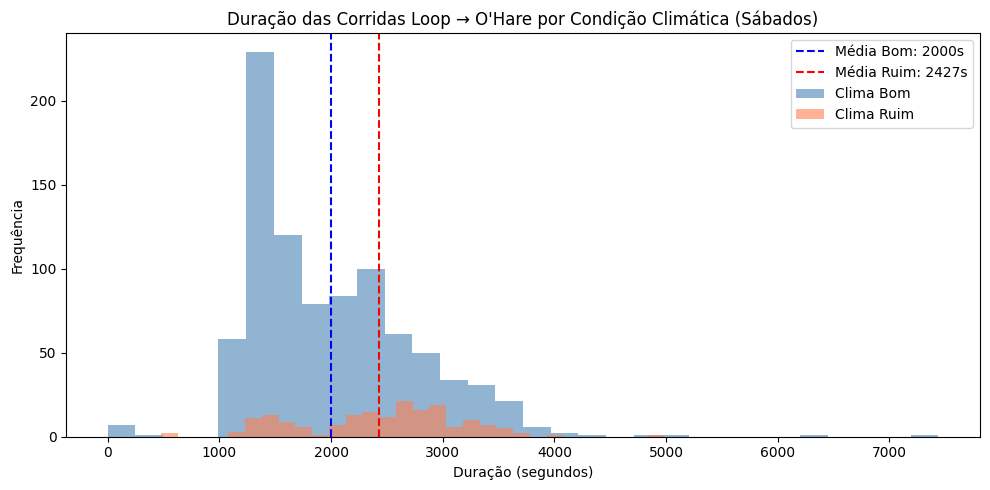

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(good_weather, bins=30, alpha=0.6, label='Clima Bom', color='steelblue')
plt.hist(bad_weather,  bins=30, alpha=0.6, label='Clima Ruim', color='coral')
plt.axvline(good_weather.mean(), color='blue', linestyle='--',
            label=f'Média Bom: {good_weather.mean():.0f}s')
plt.axvline(bad_weather.mean(),  color='red',  linestyle='--',
            label=f'Média Ruim: {bad_weather.mean():.0f}s')
plt.title("Duração das Corridas Loop → O'Hare por Condição Climática (Sábados)")
plt.xlabel('Duração (segundos)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()